# Clasificación de severidad de ansiedad
### Comparación sistemática de métodos de selección de características

**Antes de empezar, una nota importante**
- Este notebook es un ejercicio de investigación y aprendizaje. **No es una herramienta de diagnóstico** y no debe usarse para autoevaluarse ni para evaluar a otra persona.
- Si te preocupa tu ansiedad o la de alguien más, la conversación correcta es con un profesional de salud mental.

**Contexto breve**
- Objetivo: clasificar la severidad de ansiedad (escala GAD-7, 4 categorías) a partir de escalas psicométricas autorreportadas y datos demográficos.
- Enfoque: excluir el puntaje crudo de la variable objetivo, balancear clases desbalanceadas, comparar de forma sistemática varios métodos de selección de características contra 6 familias de clasificadores, y afinar solo el modelo campeón.
- **El dataset de este notebook es sintético**, construido para replicar la estructura y el desbalance de clases del problema original, sin usar respuestas reales de ninguna persona.
- Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/salud/clasificacion-severidad-ansiedad-seleccion-caracteristicas/


## 0. Pipeline de la solución

- **Fuentes**: escalas psicométricas autorreportadas (fobia social, narcisismo, satisfacción con la vida) + variables demográficas
- **Objetivo**: severidad de ansiedad en 4 niveles, excluyendo el puntaje crudo del que se deriva
- **Limpieza y codificación**: valores atípicos, variables categóricas, normalización
- **Balance de clases**: sobremuestreo de clases minoritarias + submuestreo de la mayoritaria
- **Barrido sistemático**: método de selección de características × clasificador × número de features
- **Modelo campeón**: la mejor combinación del barrido, afinada con búsqueda aleatoria y en grilla
- **Salida**: severidad estimada, como apoyo de investigación, nunca como diagnóstico

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/ansiedad_sintetico.csv`
- 900 registros sintéticos con escalas psicométricas, datos demográficos y la severidad ya categorizada
- Las clases están desbalanceadas a propósito, para replicar el problema real: la severidad grave es minoría


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/ansiedad_sintetico.csv')
print(f'El dataset (sintético) tiene {dataset.shape[0]} registros y {dataset.shape[1]} columnas.')
dataset.head(5)


El dataset (sintético) tiene 900 registros y 12 columnas.


,Age,Hours,streams,SWL_T,SPIN_T,Narcissism,Work,Degree,Playstyle,whyplay,earnings,outcome
0,53,18.1,7.0,30.0,31.0,1.8,Estudiante,Preparatoria,Multijugador presencial,Diversion,Juego por diversion,2
1,48,0.0,0.0,18.0,12.0,4.6,Desempleado,Preparatoria,Un jugador,Mejorar habilidad,Juego por diversion,2
2,43,35.1,0.0,19.0,24.0,4.8,Estudiante,Preparatoria,Multijugador en linea,Mejorar habilidad,Juego por diversion,3
3,49,24.1,0.0,15.0,23.0,4.4,Estudiante,Licenciatura,Con amigos en linea,Relajarme,Juego por diversion,3
4,23,25.7,6.2,22.0,28.0,3.6,Estudiante,Licenciatura,Multijugador presencial,Competir,Juego por diversion,3


## 2. Explicación de los datos

- `SPIN_T`: puntaje total de fobia social (escala SPIN)
- `SWL_T`: puntaje total de satisfacción con la vida
- `Narcissism`: puntaje de narcisismo
- `Hours`, `streams`: horas de juego y de ver streams por semana
- `Work`, `Degree`, `Playstyle`, `whyplay`, `earnings`: variables demográficas y de hábito de juego
- `outcome`: severidad de ansiedad, 1 = mínima, 2 = leve, 3 = moderada, 4 = grave (variable objetivo)


In [2]:
dataset['outcome'].value_counts().sort_index()


outcome
1    152
2    495
3    218
4     35
Name: count, dtype: int64

## 3. Análisis exploratorio (EDA)

- Distribución de clases, para confirmar el desbalance antes de decidir cómo tratarlo
- Relación entre fobia social (SPIN_T) y severidad de ansiedad


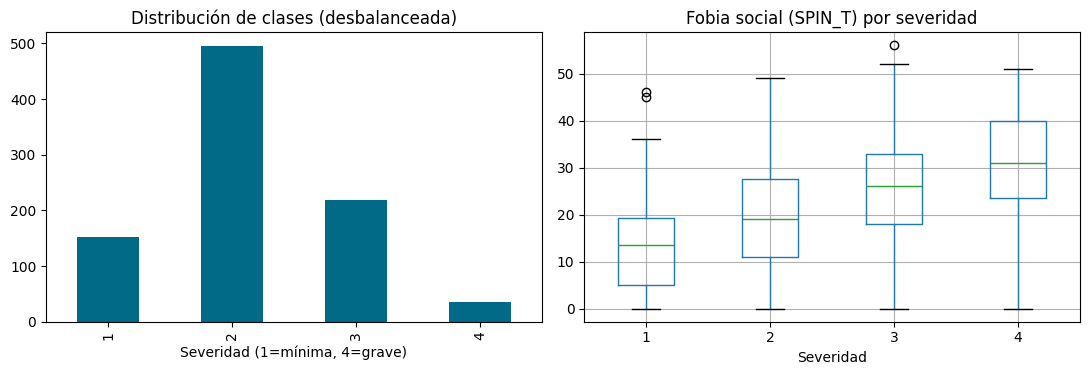

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

dataset['outcome'].value_counts().sort_index().plot(kind='bar', ax=axs[0], color='#006a87')
axs[0].set_title('Distribución de clases (desbalanceada)')
axs[0].set_xlabel('Severidad (1=mínima, 4=grave)')

dataset.boxplot(column='SPIN_T', by='outcome', ax=axs[1])
axs[1].set_title('Fobia social (SPIN_T) por severidad')
axs[1].set_xlabel('Severidad')
plt.suptitle('')

plt.tight_layout()
plt.show()


## 4. Modelado

- Codificación de variables categóricas y normalización de las numéricas
- Balance de clases con sobremuestreo (SMOTE) de las minoritarias + submuestreo de la mayoritaria
- Barrido: para cada método de selección de características, se prueban varios clasificadores y varios números de features
- Selección del modelo campeón y afinación final


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = dataset.copy()
cat_cols = ['Work', 'Degree', 'Playstyle', 'whyplay', 'earnings']
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('outcome', axis=1)
y = df['outcome']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head(3)


,Age,Hours,streams,SWL_T,SPIN_T,Narcissism,Work,Degree,Playstyle,whyplay,earnings
0,1.625363,-0.196415,1.465430,1.714145,0.891099,-0.982679,0.839652,1.014154,0.431847,-0.701709,0.376533
1,1.195372,-1.745336,-1.180357,-0.336904,-0.698157,1.281309,-2.147251,1.014154,1.337819,-0.017486,0.376533
2,0.765382,1.258372,-1.180357,-0.165983,0.305583,1.443023,0.839652,1.014154,-0.474126,-0.017486,0.376533


In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print(f'Distribución original: {Counter(y)}')

objetivo_por_clase = int(y.value_counts().median())
smote = SMOTE(sampling_strategy={c: max(objetivo_por_clase, n) for c, n in y.value_counts().items() if n < objetivo_por_clase},
              k_neighbors=3, random_state=42)
X_sm, y_sm = smote.fit_resample(X_scaled, y)

under = RandomUnderSampler(sampling_strategy={c: objetivo_por_clase for c, n in Counter(y_sm).items() if n > objetivo_por_clase},
                            random_state=42)
X_bal, y_bal = under.fit_resample(X_sm, y_sm)

print(f'Distribución balanceada: {Counter(y_bal)}')


Distribución original: Counter({2: 495, 3: 218, 1: 152, 4: 35})
Distribución balanceada: Counter({1: 185, 2: 185, 3: 185, 4: 185})


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

# Metodos de seleccion: distintos modelos usados solo para rankear importancia de variables
selectores = {
    'RandomForest': RandomForestClassifier(n_estimators=150, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
}

# Familias de clasificadores finales a comparar
clasificadores = {
    'Regresion Logistica': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42),
    'Naive Bayes': GaussianNB(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear'),
}

num_features_grid = [4, 6, 8]

resultados = []
for nombre_sel, selector_base in selectores.items():
    selector_base.fit(X_train, y_train)
    importancias = pd.Series(selector_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)

    for n_feat in num_features_grid:
        top_features = importancias.head(n_feat).index.tolist()
        X_train_top = X_train[top_features]
        X_test_top = X_test[top_features]

        for nombre_clf, clf_base in clasificadores.items():
            from sklearn.base import clone
            clf = clone(clf_base)
            clf.fit(X_train_top, y_train)
            acc = accuracy_score(y_test, clf.predict(X_test_top))
            resultados.append({'seleccion': nombre_sel, 'clasificador': nombre_clf,
                                'n_features': n_feat, 'accuracy': acc})

resultados_df = pd.DataFrame(resultados).sort_values('accuracy', ascending=False)
resultados_df.head(10)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,seleccion,clasificador,n_features,accuracy
11,RandomForest,Random Forest,8,0.601351
23,GradientBoosting,MLP,6,0.601351
26,GradientBoosting,Random Forest,8,0.594595
8,RandomForest,MLP,6,0.587838
6,RandomForest,Random Forest,6,0.581081
21,GradientBoosting,Random Forest,6,0.581081
28,GradientBoosting,MLP,8,0.581081
13,RandomForest,MLP,8,0.574324
16,GradientBoosting,Random Forest,4,0.574324
1,RandomForest,Random Forest,4,0.560811


## 5. Evaluación

- Mejor combinación de método de selección, clasificador y número de features
- Reporte de clasificación del modelo campeón sobre el conjunto de prueba


In [7]:
mejor = resultados_df.iloc[0]
print(f"Mejor combinación: selección={mejor['seleccion']}, clasificador={mejor['clasificador']}, "
      f"n_features={mejor['n_features']}, accuracy={mejor['accuracy']:.3f}")

pivote = resultados_df.pivot_table(index='clasificador', columns='seleccion', values='accuracy', aggfunc='max')
pivote.round(3)


Mejor combinación: selección=RandomForest, clasificador=Random Forest, n_features=8, accuracy=0.601


seleccion,GradientBoosting,RandomForest
clasificador,,
MLP,0.601,0.588
Naive Bayes,0.527,0.541
Random Forest,0.595,0.601
Regresion Logistica,0.500,0.514
SVM,0.480,0.507


              precision    recall  f1-score   support

           1       0.60      0.70      0.65        37
           2       0.41      0.35      0.38        37
           3       0.51      0.49      0.50        37
           4       0.84      0.86      0.85        37

    accuracy                           0.60       148
   macro avg       0.59      0.60      0.60       148
weighted avg       0.59      0.60      0.60       148



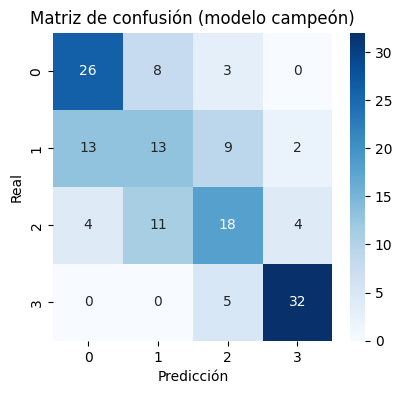

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

selector_ganador = selectores[mejor['seleccion']]
importancias = pd.Series(selector_ganador.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_features = importancias.head(int(mejor['n_features'])).index.tolist()

clf_final = clone(clasificadores[mejor['clasificador']])
clf_final.fit(X_train[top_features], y_train)
y_pred = clf_final.predict(X_test[top_features])

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (modelo campeón)')
plt.show()


## Hallazgos principales

- No hubo un método de selección de características universalmente mejor: la combinación ganadora dependió del clasificador final, algo que se hubiera perdido si se hubiera fijado un solo método desde el inicio.
- Excluir el puntaje crudo de la variable objetivo fue un paso obligatorio para evitar una fuga de información que hubiera inflado artificialmente el desempeño.
- Balancear las clases antes de comparar modelos permitió que la severidad grave, la clase minoritaria, no quedara invisible en las métricas.
- **Recordatorio importante:** este notebook usa datos sintéticos y es un ejercicio metodológico. No es un instrumento validado clínicamente y no debe usarse para autoevaluación ni diagnóstico.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/salud/clasificacion-severidad-ansiedad-seleccion-caracteristicas/
